# House Prices — Simple Polynomial Regression

A beginner-friendly degree-2 polynomial regression notebook. No advanced ensemble models are used.

## 1. Imports

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 100)

## 2. Load data

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT
train = pd.read_csv(DATA / 'train.csv')
test = pd.read_csv(DATA / 'test.csv')
print('Train:', train.shape)
print('Test :', test.shape)
train.head()

Train: (1460, 81)
Test : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Basic understanding

In [3]:
print(train['SalePrice'].describe())
print('Duplicate rows:', train.duplicated().sum())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Duplicate rows: 0


## 4. Select simple numeric features

In [4]:
FEATURES = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
TARGET = 'SalePrice'
X = train[FEATURES].copy()
y = train[TARGET].copy()
print(X.isna().sum())
print('Test missing values:')
print(test[FEATURES].isna().sum())

OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
FullBath       0
YearBuilt      0
dtype: int64
Test missing values:
OverallQual    0
GrLivArea      0
GarageCars     1
TotalBsmtSF    1
FullBath       0
YearBuilt      0
dtype: int64


## 5. Visual checks

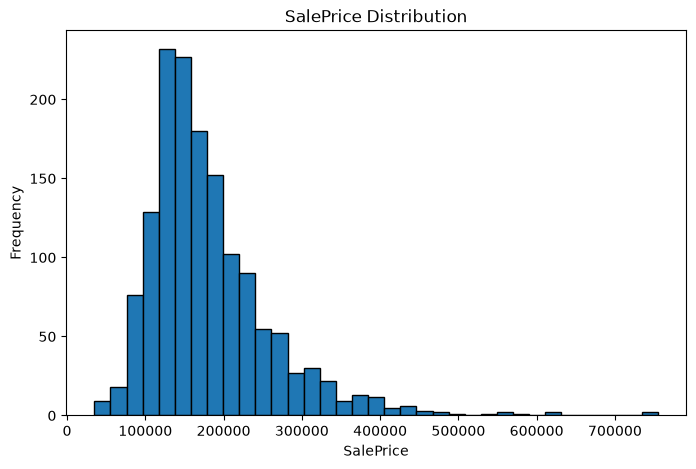

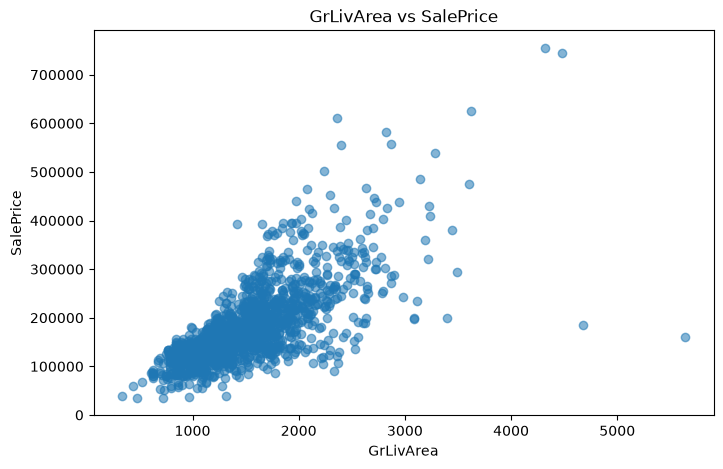

In [5]:
plt.figure(figsize=(8,5))
plt.hist(y, bins=35, edgecolor='black')
plt.title('SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(train['GrLivArea'], y, alpha=0.55)
plt.title('GrLivArea vs SalePrice')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

## 6. Train-validation split

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(X_train.shape, X_valid.shape)

(1168, 6) (292, 6)


## 7. Median imputation learned from training data

In [7]:
imputer = SimpleImputer(strategy='median')
X_train_clean = imputer.fit_transform(X_train)
X_valid_clean = imputer.transform(X_valid)

## 8. Degree-2 polynomial features

In [8]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_clean)
X_valid_poly = poly.transform(X_valid_clean)
print('Original feature count:', X_train.shape[1])
print('Polynomial feature count:', X_train_poly.shape[1])
print(poly.get_feature_names_out(FEATURES))

Original feature count: 6
Polynomial feature count: 27
['OverallQual' 'GrLivArea' 'GarageCars' 'TotalBsmtSF' 'FullBath'
 'YearBuilt' 'OverallQual^2' 'OverallQual GrLivArea'
 'OverallQual GarageCars' 'OverallQual TotalBsmtSF' 'OverallQual FullBath'
 'OverallQual YearBuilt' 'GrLivArea^2' 'GrLivArea GarageCars'
 'GrLivArea TotalBsmtSF' 'GrLivArea FullBath' 'GrLivArea YearBuilt'
 'GarageCars^2' 'GarageCars TotalBsmtSF' 'GarageCars FullBath'
 'GarageCars YearBuilt' 'TotalBsmtSF^2' 'TotalBsmtSF FullBath'
 'TotalBsmtSF YearBuilt' 'FullBath^2' 'FullBath YearBuilt' 'YearBuilt^2']


## 9. Fit plain linear regression

In [9]:
model = LinearRegression()
model.fit(X_train_poly, y_train)
valid_pred = model.predict(X_valid_poly)

## 10. Evaluate

In [10]:
mae = mean_absolute_error(y_valid, valid_pred)
rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
r2 = r2_score(y_valid, valid_pred)
metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
metrics

{'MAE': 21267.84726557786,
 'RMSE': 32248.790520466453,
 'R2': 0.8644145683063053}

## 11. Actual vs predicted

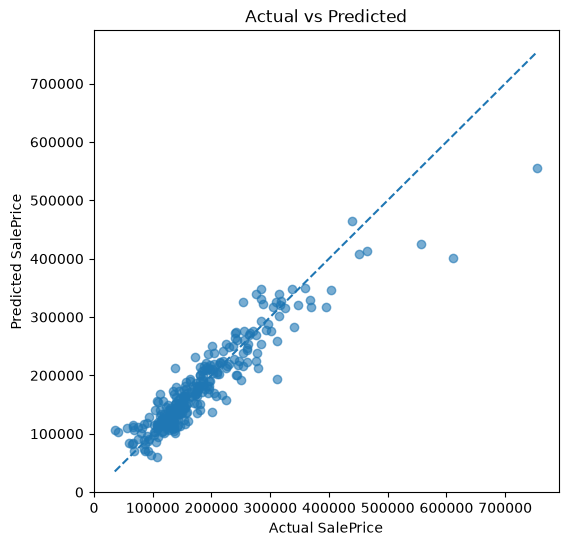

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(y_valid, valid_pred, alpha=0.6)
lo = min(y_valid.min(), valid_pred.min())
hi = max(y_valid.max(), valid_pred.max())
plt.plot([lo, hi], [lo, hi], '--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted')
plt.show()

## 12. Simple error analysis

In [12]:
errors = pd.DataFrame({
    'Actual': y_valid,
    'Predicted': valid_pred
})
errors['AbsoluteError'] = (errors['Actual'] - errors['Predicted']).abs()
errors.sort_values('AbsoluteError', ascending=False).head(10)

,Actual,Predicted,AbsoluteError
898,611657,401961.601699,209695.398301
691,755000,554894.952815,200105.047185
1046,556581,424328.154758,132252.845242
218,311500,193645.519092,117854.480908
774,395000,316740.923627,78259.076373
1088,137500,211842.761356,74342.761356
581,253293,326174.421199,72881.421199
916,35311,107250.372725,71939.372725
451,280000,212752.917527,67247.082473
607,225000,158298.201032,66701.798968


## 13. Refit on all training data and create submission

In [13]:
full_imputer = SimpleImputer(strategy='median')
X_full = full_imputer.fit_transform(X)
X_test = full_imputer.transform(test[FEATURES])
full_poly = PolynomialFeatures(degree=2, include_bias=False)
X_full_poly = full_poly.fit_transform(X_full)
X_test_poly = full_poly.transform(X_test)
final_model = LinearRegression()
final_model.fit(X_full_poly, y)
test_pred = np.maximum(final_model.predict(X_test_poly), 0)
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': test_pred})
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
submission.to_csv(OUTPUTS / 'polynomial_submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,117035.337745
1,1462,164982.159446
2,1463,168338.879247
3,1464,183093.297480
4,1465,206428.232249


## 14. Conclusion
This notebook demonstrates polynomial regression transparently. The next improvement should be residual analysis or a degree-1 versus degree-2 comparison—not an immediate jump to advanced ensemble models.